# Étape 4 : Communautés globales du graphe CV–Job

Ce notebook détecte des communautés mélangeant CV et Jobs à l'aide de **Label Propagation**, puis
évalue et interprète la partition. Il ne construit pas de graphe de compétences.

## 1. Chargement et contrôles rapides

Nous rechargeons le graphe validé à l'étape 2. Les contrôles suivants vérifient seulement que le
bon objet a été chargé ; ils ne répètent pas l'analyse structurelle.

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import copy
import json
import pickle
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
FIGURES_DIR = ROOT / "figures" / "step4"
RESULTS_DIR = ROOT / "results"
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with (PROCESSED_DIR / "cv_job_graph.pkl").open("rb") as file:
    G = pickle.load(file)

assert G.number_of_nodes() == 12_500
assert G.number_of_edges() == 75_000
assert nx.is_bipartite(G)
display(pd.Series({
    "n_nodes": G.number_of_nodes(),
    "n_edges": G.number_of_edges(),
    "is_bipartite": nx.is_bipartite(G),
}, name="valeur").to_frame())

,valeur
n_nodes,12500
n_edges,75000
is_bipartite,True


## 2. Qu'est-ce qu'une communauté ?

Une **communauté** est un groupe de nœuds qui possède beaucoup de liens internes et relativement
peu de liens vers le reste du graphe. Dans notre cas, une communauté globale mélange volontairement
des CV et des Jobs : par exemple, un groupe peut associer des CV Data Analyst/Data Scientist à des
Jobs BI/Data, tandis qu'un autre peut regrouper Software Engineering ou Marketing.

Cette analyse cherche donc des zones structurelles du réseau de matching. L'interprétation des
rôles, industries et compétences vient seulement après la détection ; elle ne doit pas être imposée
à l'algorithme.

## 3. Label Propagation : 

Label Propagation fait circuler des étiquettes dans le graphe :

1. chaque nœud reçoit d'abord un label unique ;
2. l'ordre des nœuds est mélangé aléatoirement ;
3. chaque nœud observe les labels de ses voisins ;
4. il adopte le label le plus fréquent ;
5. en cas d'égalité, un label majoritaire est tiré au hasard ;
6. on recommence jusqu'à ce qu'aucun label ne change, ou jusqu'à `max_iter`.

L'intuition est qu'un label fréquent localement se propage dans une zone fortement connectée.
L'algorithme est rapide car il ne compare pas toutes les paires de nœuds. En revanche, le mélange
et les égalités le rendent **non déterministe** : deux seeds peuvent produire des partitions
différentes. Sur un graphe biparti, un label alterne entre CV et Jobs ; une communauté globale peut
donc naturellement contenir les deux types de nœuds.

In [2]:
def label_propagation_manual(G, seed=42, max_iter=100):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    labels = {node: index for index, node in enumerate(nodes)}

    for iteration in range(1, max_iter + 1):
        rng.shuffle(nodes)
        n_changes = 0

        for node in nodes:
            neighbors = list(G.neighbors(node))
            if not neighbors:  # Un isolé conserve son label unique.
                continue

            counts = Counter(labels[neighbor] for neighbor in neighbors)
            max_count = max(counts.values())
            majority_labels = [label for label, count in counts.items() if count == max_count]
            new_label = rng.choice(majority_labels)

            if new_label != labels[node]:
                labels[node] = new_label
                n_changes += 1

        if n_changes == 0:
            return labels, iteration, True

    return labels, max_iter, False

## 4. Des labels à une partition

Une partition est une collection $C_1, C_2, \ldots, C_k$ d'ensembles disjoints dont l'union est
l'ensemble des nœuds. Ici, chaque nœud possède exactement un label : nous regroupons donc les nœuds
ayant le même label dans un même ensemble. Cette représentation est celle attendue par la fonction
de modularité de NetworkX.

In [3]:
def labels_to_communities(labels):
    groups = defaultdict(set)
    for node, label in labels.items():
        groups[label].add(node)
    return list(groups.values())

## 5. Modularité : définition et implémentation

La modularité compare le nombre de liens internes observés à celui attendu dans un graphe aléatoire
conservant les degrés. Pour une partition en communautés $c$ :

$$Q = \sum_c \left[\frac{l_c}{m} - \left(\frac{k_c}{2m}\right)^2\right],$$

où $l_c$ est le nombre d'arêtes internes à $c$, $k_c$ la somme des degrés de ses nœuds, et $m$ le
nombre total d'arêtes. Une modularité plus élevée indique davantage de structure interne que le
modèle de référence. Pour éviter une boucle en $O(n^2)$, le code parcourt chaque nœud puis chaque
arête une seule fois : complexité approximative $O(n+m)$ par partition.

In [4]:
def compute_modularity_manual(G, communities):
    m = G.number_of_edges()
    if m == 0:
        raise ValueError("La modularité n'est pas définie pour un graphe sans arêtes.")

    community_of = {
        node: community_index
        for community_index, community in enumerate(communities)
        for node in community
    }
    if set(community_of) != set(G.nodes()):
        raise ValueError("La partition doit contenir chaque nœud exactement une fois.")

    degree_sums = [0] * len(communities)
    internal_edges = [0] * len(communities)

    for node, degree in G.degree():
        degree_sums[community_of[node]] += degree

    for u, v in G.edges():
        community_u = community_of[u]
        if community_u == community_of[v]:
            internal_edges[community_u] += 1

    return sum(
        l_c / m - (k_c / (2 * m)) ** 2
        for l_c, k_c in zip(internal_edges, degree_sums)
    )

## 6. Limite liée au caractère biparti

Nous utilisons ici la **modularité standard vue en cours**, dont le modèle nul est le modèle de
configuration classique. Notre graphe est pourtant biparti : les arêtes CV–CV et Job–Job sont
interdites, alors que ce modèle de référence général ne représente pas explicitement cette
contrainte. Des variantes de modularité bipartite existent, mais elles ne figurent pas dans les
supports fournis. Pour rester cohérent avec le cours et le cahier des charges, nous conservons la
formule standard et documentons cette limite au lieu de changer silencieusement de métrique.

## 7. Cinq runs pour gérer le non-déterminisme

Un seul run pourrait donner une image accidentelle de la structure. Nous exécutons donc la fonction
manuelle avec les seeds `[0, 1, 2, 3, 4]`. Pour chaque résultat, nous mesurons convergence, nombre
de communautés, modularité et tailles extrêmes. La partition principale sera celle de modularité
maximale : ce critère rend le choix explicite et reproductible, sans prétendre que la partition est
une vérité unique.

In [5]:
SEEDS = [0, 1, 2, 3, 4]
MAX_ITER = 100
run_rows = []
run_partitions = {}
run_labels = {}

for seed in SEEDS:
    labels, iterations, converged = label_propagation_manual(G, seed=seed, max_iter=MAX_ITER)
    communities = labels_to_communities(labels)
    modularity_manual = compute_modularity_manual(G, communities)
    modularity_nx = nx.algorithms.community.modularity(G, communities)
    difference = abs(modularity_manual - modularity_nx)
    assert difference < 1e-10

    sizes = [len(community) for community in communities]
    run_rows.append({
        "seed": seed,
        "iterations": iterations,
        "converged": converged,
        "n_communities": len(communities),
        "modularity_manual": modularity_manual,
        "modularity_networkx": modularity_nx,
        "modularity_difference": difference,
        "smallest_community": min(sizes),
        "largest_community": max(sizes),
    })
    run_partitions[seed] = communities
    run_labels[seed] = labels

runs_df = pd.DataFrame(run_rows).sort_values("seed").reset_index(drop=True)
display(runs_df)

best_row = runs_df.loc[runs_df["modularity_manual"].idxmax()]
best_seed = int(best_row["seed"])
best_communities_raw = run_partitions[best_seed]
print("Seed retenue :", best_seed, "(modularité maximale)")

,seed,iterations,converged,n_communities,modularity_manual,modularity_networkx,modularity_difference,smallest_community,largest_community
0,0,25,True,37,0.872456,0.872456,0.0,1,1628
1,1,21,True,37,0.872455,0.872455,0.0,1,1628
2,2,9,True,37,0.872455,0.872455,0.0,1,1628
3,3,10,True,37,0.872457,0.872457,0.0,1,1628
4,4,21,True,37,0.872458,0.872458,0.0,1,1628


Seed retenue : 4 (modularité maximale)


## 8. Vérification manuelle contre NetworkX

Pour le run retenu, nous recalculons séparément la modularité avec notre formule et avec NetworkX.
La différence absolue doit être négligeable ; sinon, la suite est arrêtée par une assertion. Cette
double vérification valide l'implémentation pédagogique avant toute interprétation.

In [6]:
best_modularity_manual = compute_modularity_manual(G, best_communities_raw)
best_modularity_nx = nx.algorithms.community.modularity(G, best_communities_raw)
modularity_difference = abs(best_modularity_manual - best_modularity_nx)
display(pd.Series({
    "modularity_manual": best_modularity_manual,
    "modularity_networkx": best_modularity_nx,
    "absolute_difference": modularity_difference,
}, name="valeur").to_frame())
assert modularity_difference < 1e-10

,valeur
modularity_manual,0.872458
modularity_networkx,0.872458
absolute_difference,0.000000


## 9. Statistiques de la partition choisie

Les labels numériques initiaux n'ont aucun sens métier. Nous réindexons les communautés par taille
décroissante afin que `community_id=0` désigne la plus grande. Nous vérifions ensuite les trois
propriétés d'une partition : ensembles non vides, absence de recouvrement et union égale à tous les
nœuds. Les effectifs CV/Job montrent si chaque communauté globale mélange bien les deux partitions.

,taille
minimum,1.000000
median,1.000000
mean,337.837838
maximum,1628.000000


,community_id,size,n_cv,n_jobs
0,0,1628,1308,320
1,1,1571,1239,332
2,2,1565,1277,288
3,3,1562,1250,312
4,4,1559,1245,314
5,5,1550,1254,296
6,6,1531,1213,318
7,7,1505,1185,320
8,8,1,1,0
9,9,1,1,0


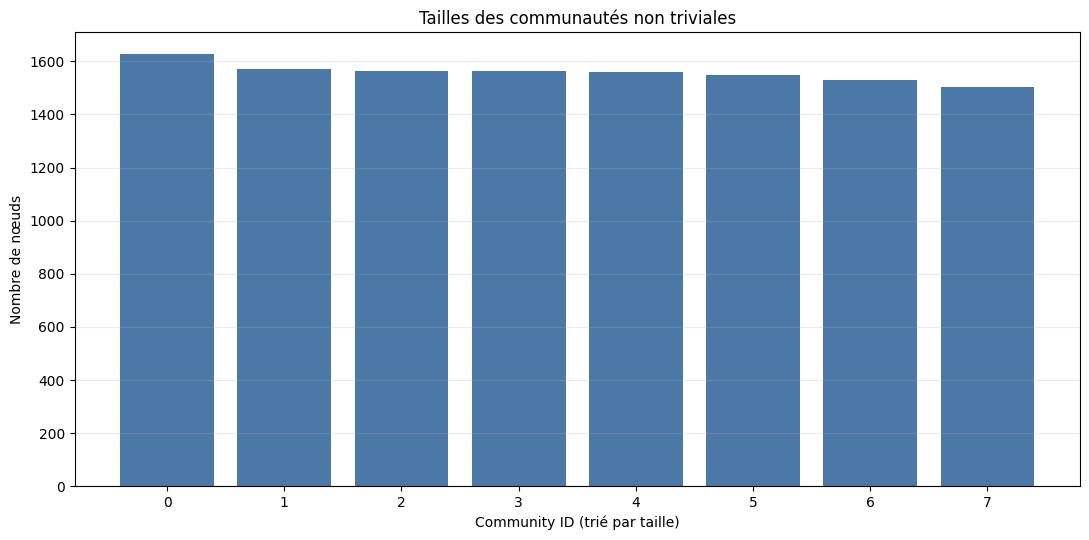

In [7]:
best_communities = sorted(best_communities_raw, key=lambda community: (-len(community), min(community)))
community_of = {
    node: community_id
    for community_id, community in enumerate(best_communities)
    for node in community
}

assert all(best_communities)
assert sum(len(community) for community in best_communities) == G.number_of_nodes()
assert set().union(*best_communities) == set(G.nodes())
assert len(community_of) == G.number_of_nodes()

partition_rows = []
for community_id, community in enumerate(best_communities):
    n_cv = sum(G.nodes[node]["node_type"] == "CV" for node in community)
    n_jobs = len(community) - n_cv
    partition_rows.append({"community_id": community_id, "size": len(community), "n_cv": n_cv, "n_jobs": n_jobs})

partition_stats = pd.DataFrame(partition_rows)
size_stats = {
    "minimum": int(partition_stats["size"].min()),
    "median": float(partition_stats["size"].median()),
    "mean": float(partition_stats["size"].mean()),
    "maximum": int(partition_stats["size"].max()),
}
display(pd.Series(size_stats, name="taille").to_frame())
display(partition_stats.head(20))

top_sizes = partition_stats[partition_stats["size"] > 1]
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(top_sizes["community_id"].astype(str), top_sizes["size"], color="#4C78A8")
ax.set(title="Tailles des communautés non triviales", xlabel="Community ID (trié par taille)", ylabel="Nombre de nœuds")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "community_sizes.png", dpi=170, bbox_inches="tight")
plt.show()

## 10. Profils sémantiques des communautés

La détection précédente utilise uniquement les arêtes. Pour interpréter les communautés assez
grandes (`size >= 50`), nous comptons ensuite les catégories et compétences les plus fréquentes.
Ce comptage descriptif ne renomme pas les communautés avec un LLM et ne modifie pas la partition.
Une communauté est décrite seulement par les attributs réellement dominants observés.

In [8]:
PROFILE_MIN_SIZE = 50

def as_list(value):
    if value is None:
        return []
    return value.tolist() if hasattr(value, "tolist") else list(value)

def top_values(values, n=5):
    return [{"value": value, "count": count} for value, count in Counter(values).most_common(n)]

community_profiles = []
for community_id, community in enumerate(best_communities):
    if len(community) < PROFILE_MIN_SIZE:
        continue

    cv_members = [node for node in community if G.nodes[node]["node_type"] == "CV"]
    job_members = [node for node in community if G.nodes[node]["node_type"] == "Job"]
    all_members = cv_members + job_members
    resume_skills = [skill for node in cv_members for skill in as_list(G.nodes[node].get("skills", []))]
    job_skills = [skill for node in job_members for skill in as_list(G.nodes[node].get("must_have_skills", []))]

    community_profiles.append({
        "community_id": community_id,
        "size": len(community),
        "n_cv": len(cv_members),
        "n_jobs": len(job_members),
        "top_roles_cv": top_values([G.nodes[node].get("role") for node in cv_members]),
        "top_job_titles": top_values([G.nodes[node].get("job_title") for node in job_members]),
        "top_industries": top_values([G.nodes[node].get("industry") for node in all_members]),
        "top_seniority": top_values([G.nodes[node].get("seniority") for node in all_members]),
        "top_resume_skills": top_values(resume_skills),
        "top_job_must_have_skills": top_values(job_skills),
    })

(RESULTS_DIR / "step4_community_profiles.json").write_text(
    json.dumps(community_profiles, indent=2, ensure_ascii=False), encoding="utf-8"
)

profile_display = pd.DataFrame([{**profile, **{
    field: ", ".join(f"{item['value']} ({item['count']})" for item in profile[field])
    for field in ["top_roles_cv", "top_job_titles", "top_industries", "top_seniority", "top_resume_skills", "top_job_must_have_skills"]
}} for profile in community_profiles])
display(profile_display.head(15))

,community_id,size,n_cv,n_jobs,top_roles_cv,top_job_titles,top_industries,top_seniority,top_resume_skills,top_job_must_have_skills
0,0,1628,1308,320,"Backend Engineer (453), Software Engineer (432...","Backend Engineer (117), Full Stack Engineer (1...","Retail (181), SaaS (176), EdTech (174), Logist...","Junior (548), Senior (545), Mid (535)","JavaScript (863), Python (863), OOP (856), RES...","Databases (140), CI/CD (139), Git (137), Unit ..."
1,1,1571,1239,332,"Financial Analyst (431), FP&A Analyst (416), J...","Junior Accountant (118), FP&A Analyst (110), F...","SaaS (179), E-commerce (163), FinTech (162), R...","Mid (540), Junior (528), Senior (503)","Reporting (821), Financial Modeling (819), For...","Valuation (146), Reporting (141), Budgeting (1..."
2,2,1565,1277,288,"Product Manager (450), Associate Product Manag...","Technical Product Manager (104), Associate Pro...","Gaming (179), E-commerce (168), Travel (162), ...","Mid (531), Junior (530), Senior (504)","Prioritization (855), Agile (837), Product Str...","User Research (128), Analytics (119), Roadmap ..."
3,3,1562,1250,312,"BI Analyst (426), Business Analyst (422), Data...","Business Analyst (120), BI Analyst (103), Data...","Retail (179), SaaS (166), Gaming (163), Health...","Mid (538), Junior (521), Senior (503)","Tableau (850), Power BI (835), Python (830), D...","A/B Testing (146), Power BI (135), Data Visual..."
4,4,1559,1245,314,"Sales Representative (458), Business Developme...","Sales Representative (114), Account Executive ...","Travel (168), Logistics (163), E-commerce (162...","Junior (538), Mid (525), Senior (496)","Forecasting (833), Prospecting (825), CRM (816...","Forecasting (145), Outbound Outreach (139), Ac..."
5,5,1550,1254,296,"Marketing Manager (454), Content Marketer (409...","Content Marketer (106), Performance Marketer (...","Cybersecurity (176), SaaS (165), Retail (164),...","Senior (531), Junior (530), Mid (489)","Content Marketing (845), A/B Testing (829), La...","Content Marketing (126), SEO (125), Google Ads..."
6,6,1531,1213,318,"Operations Manager (424), Project Manager (396...","Project Manager (128), Program Coordinator (10...","Retail (173), Logistics (168), Gaming (161), F...","Junior (534), Senior (503), Mid (494)","Process Improvement (809), Reporting (795), Ti...","Project Planning (145), Stakeholder Communicat..."
7,7,1505,1185,320,"Technical Support Specialist (413), Customer S...","Technical Support Specialist (112), Customer S...","Healthcare (170), FinTech (160), Retail (160),...","Mid (528), Junior (492), Senior (485)","Root Cause Analysis (794), Intercom (791), Com...","Intercom (143), SLA (137), Ticketing (131), Co..."


## 11. Lecture des principales communautés

Le texte ci-dessous est construit directement à partir des trois catégories dominantes de chaque
profil. Il s'agit d'une aide à la lecture, pas d'un nom automatique ni d'une explication causale.

In [9]:
interpretation_lines = ["### Principales communautés observées"]
for profile in community_profiles[:5]:
    roles = ", ".join(item["value"] for item in profile["top_roles_cv"][:3])
    jobs = ", ".join(item["value"] for item in profile["top_job_titles"][:3])
    skills = ", ".join(item["value"] for item in profile["top_resume_skills"][:3])
    interpretation_lines.append(
        f"- **Communauté {profile['community_id']}** ({profile['size']} nœuds, "
        f"{profile['n_cv']} CV / {profile['n_jobs']} Jobs) : rôles CV dominants — {roles}; "
        f"Jobs dominants — {jobs}; compétences CV fréquentes — {skills}."
    )
display(Markdown("\n".join(interpretation_lines)))

### Principales communautés observées
- **Communauté 0** (1628 nœuds, 1308 CV / 320 Jobs) : rôles CV dominants — Backend Engineer, Software Engineer, Full Stack Engineer; Jobs dominants — Backend Engineer, Full Stack Engineer, Software Engineer; compétences CV fréquentes — JavaScript, Python, OOP.
- **Communauté 1** (1571 nœuds, 1239 CV / 332 Jobs) : rôles CV dominants — Financial Analyst, FP&A Analyst, Junior Accountant; Jobs dominants — Junior Accountant, FP&A Analyst, Financial Analyst; compétences CV fréquentes — Reporting, Financial Modeling, Forecasting.
- **Communauté 2** (1565 nœuds, 1277 CV / 288 Jobs) : rôles CV dominants — Product Manager, Associate Product Manager, Technical Product Manager; Jobs dominants — Technical Product Manager, Associate Product Manager, Product Manager; compétences CV fréquentes — Prioritization, Agile, Product Strategy.
- **Communauté 3** (1562 nœuds, 1250 CV / 312 Jobs) : rôles CV dominants — BI Analyst, Business Analyst, Data Analyst; Jobs dominants — Business Analyst, BI Analyst, Data Analyst; compétences CV fréquentes — Tableau, Power BI, Python.
- **Communauté 4** (1559 nœuds, 1245 CV / 314 Jobs) : rôles CV dominants — Sales Representative, Business Development Manager, Account Executive; Jobs dominants — Sales Representative, Account Executive, Business Development Manager; compétences CV fréquentes — Forecasting, Prospecting, CRM.

## 12. Visualisation d'un échantillon multi-communautés

Le graphe complet serait illisible. Nous choisissons les trois plus grandes communautés et, dans
chacune, un Job très connecté accompagné d'au plus huit CV voisins de la même communauté. La couleur
représente la communauté ; les cercles sont les CV et les carrés les Jobs. Le layout sert uniquement
à visualiser l'échantillon, pas à mesurer les distances.

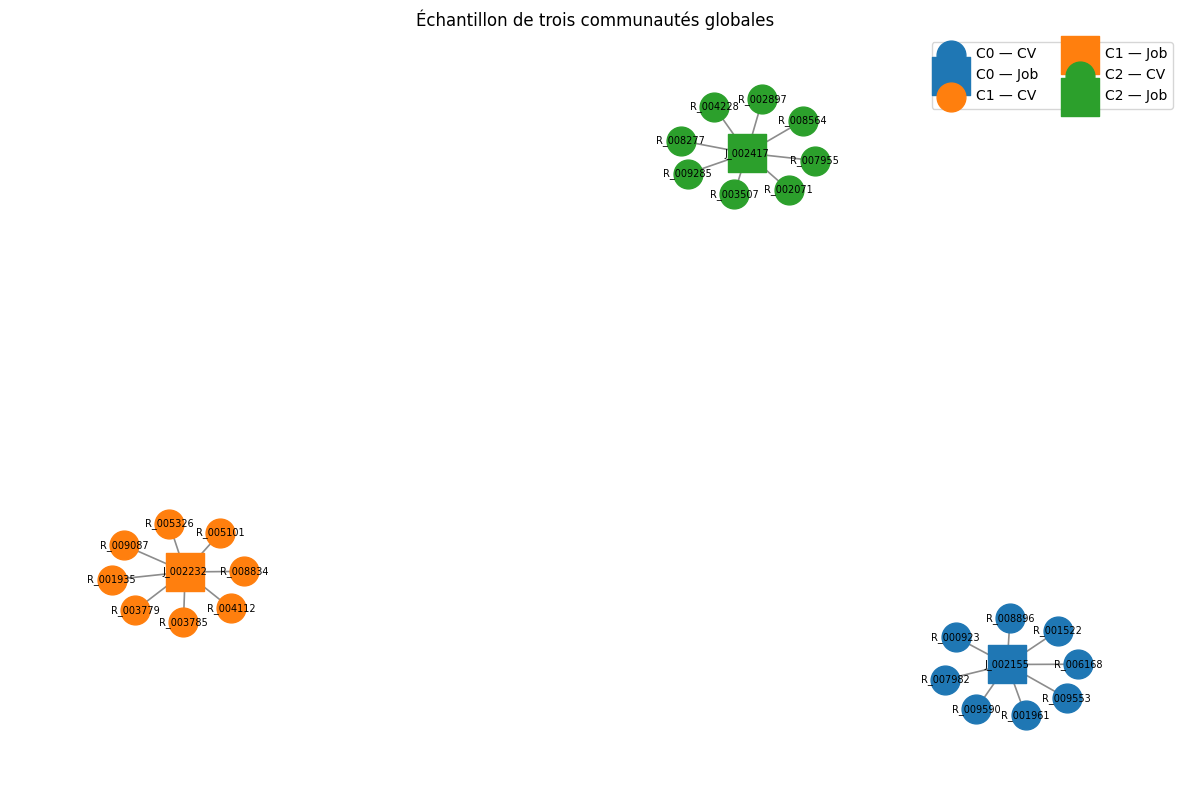

In [10]:
sample_nodes = set()
sample_community_ids = list(range(min(3, len(best_communities))))
for community_id in sample_community_ids:
    community = best_communities[community_id]
    jobs = [node for node in community if G.nodes[node]["node_type"] == "Job"]
    if not jobs:
        continue
    center = max(jobs, key=G.degree)
    neighbors = [node for node in G.neighbors(center) if node in community][:8]
    sample_nodes.update([center, *neighbors])

sample_graph = G.subgraph(sample_nodes).copy()
positions = nx.spring_layout(sample_graph, seed=42)
cmap = plt.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(12, 8))
for community_id in sample_community_ids:
    cv_sample = [node for node in sample_graph if community_of[node] == community_id and G.nodes[node]["node_type"] == "CV"]
    job_sample = [node for node in sample_graph if community_of[node] == community_id and G.nodes[node]["node_type"] == "Job"]
    color = cmap(community_id % 10)
    nx.draw_networkx_nodes(sample_graph, positions, nodelist=cv_sample, node_shape="o", node_color=[color], node_size=430, label=f"C{community_id} — CV", ax=ax)
    nx.draw_networkx_nodes(sample_graph, positions, nodelist=job_sample, node_shape="s", node_color=[color], node_size=780, label=f"C{community_id} — Job", ax=ax)

nx.draw_networkx_edges(sample_graph, positions, alpha=0.45, width=1.2, ax=ax)
nx.draw_networkx_labels(sample_graph, positions, font_size=7, ax=ax)
ax.set_title("Échantillon de trois communautés globales")
ax.legend(ncol=2)
ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "sample_communities.png", dpi=170, bbox_inches="tight")
plt.show()

## 13. Sauvegarde de l'appartenance communautaire

L'identifiant communautaire est sauvegardé séparément pour chaque nœud afin de devenir plus tard
une feature. Une **copie** du graphe reçoit aussi l'attribut `community_global`; le pickle original
reste intact.

In [11]:
membership_rows = []
for node, data in G.nodes(data=True):
    membership_rows.append({
        "node_id": node,
        "node_type": data["node_type"],
        "community_global": community_of[node],
        "role": data.get("role"),
        "job_title": data.get("job_title"),
        "seniority": data.get("seniority"),
        "industry": data.get("industry"),
    })

membership_df = pd.DataFrame(membership_rows)
membership_df.to_csv(RESULTS_DIR / "step4_global_communities.csv", index=False)

G_with_communities = G.copy()
nx.set_node_attributes(G_with_communities, community_of, "community_global")
with (PROCESSED_DIR / "cv_job_graph_with_communities.pkl").open("wb") as file:
    pickle.dump(G_with_communities, file, protocol=pickle.HIGHEST_PROTOCOL)

assert all("community_global" in data for _, data in G_with_communities.nodes(data=True))
assert all("community_global" not in data for _, data in G.nodes(data=True))
print("Appartenance sauvegardée pour", len(membership_df), "nœuds, sans modifier G.")

Appartenance sauvegardée pour 12500 nœuds, sans modifier G.


## 14. Résumé reproductible

Le JSON rassemble la méthode, les seeds, le run retenu, la vérification de modularité et les
effectifs de chaque communauté. Les nombres sont convertis en types Python standards.

In [12]:
best_run = runs_df.loc[runs_df["seed"] == best_seed].iloc[0]
community_summary = {
    "method": "manual asynchronous label propagation",
    "seeds_tested": SEEDS,
    "max_iter": MAX_ITER,
    "selected_seed": best_seed,
    "selection_reason": "highest standard modularity among tested seeds",
    "selected_iterations": int(best_run["iterations"]),
    "selected_converged": bool(best_run["converged"]),
    "n_communities": len(best_communities),
    "modularity_manual": best_modularity_manual,
    "modularity_networkx": best_modularity_nx,
    "modularity_absolute_difference": modularity_difference,
    "community_size_min": size_stats["minimum"],
    "community_size_median": size_stats["median"],
    "community_size_mean": size_stats["mean"],
    "community_size_max": size_stats["maximum"],
    "community_counts": partition_rows,
    "runs": run_rows,
    "profile_minimum_size": PROFILE_MIN_SIZE,
    "modularity_limit": "standard modularity uses a non-bipartite configuration-model reference",
}
(RESULTS_DIR / "step4_community_summary.json").write_text(
    json.dumps(community_summary, indent=2, ensure_ascii=False), encoding="utf-8"
)
display(pd.Series({key: value for key, value in community_summary.items() if key not in {"community_counts", "runs"}}, name="valeur").to_frame())

,valeur
method,manual asynchronous label propagation
seeds_tested,"[0, 1, 2, 3, 4]"
max_iter,100
selected_seed,4
selection_reason,highest standard modularity among tested seeds
selected_iterations,21
selected_converged,True
n_communities,37
modularity_manual,0.872458
modularity_networkx,0.872458


## Interprétation et conclusion

- Les cinq runs trouvent chacun **37 communautés** : huit grandes communautés mixtes CV–Job et
  29 communautés réduites à un CV isolé. La taille médiane vaut donc `1`, tandis que les huit
  groupes non triviaux comptent entre `1 505` et `1 628` nœuds.
- La seed retenue est **4**, car elle obtient la modularité standard la plus élevée :
  `0,8724577778`. Cette valeur très élevée indique une structure interne forte selon le modèle de
  référence standard. Elle doit néanmoins être nuancée : le graphe est déjà fragmenté en plusieurs
  composantes et provient d'un générateur synthétique fortement structuré par métiers.
- Les huit grandes communautés ont une cohérence sémantique nette : **Software Engineering**,
  **Finance/Accounting**, **Product Management**, **Data/Analytics**, **Sales/Business
  Development**, **Marketing**, **Operations/Project Management** et **Customer/Technical
  Support**. Les rôles, intitulés de Jobs et compétences concordent dans chaque groupe.
- Les industries et niveaux de séniorité sont beaucoup plus répartis. Les communautés semblent donc
  principalement organisées par familles de métiers et compétences, plutôt que par industrie ou
  séniorité.
- Le non-déterminisme affecte surtout le nombre d'itérations (`9` à `25`) et légèrement les
  frontières : les modularités ne diffèrent que d'environ `2,5 × 10⁻⁶`. Le nombre de communautés et
  les grandes tailles restent identiques, ce qui indique une structure macroscopique stable sur ces
  cinq runs.
- La modularité manuelle et celle de NetworkX sont identiques numériquement pour chaque seed
  (différence absolue `0`). La formule du cours est donc correctement implémentée.
- Limites : Label Propagation n'optimise pas directement la modularité ; sélectionner le meilleur de
  cinq runs réduit mais n'annule pas son instabilité. De plus, la modularité standard utilise un
  modèle de configuration non spécifiquement biparti. Sa valeur ne doit donc pas être interprétée
  comme une validation définitive des communautés CV–Job.